In [59]:
%pip install pandas numpy scikit-learn joblib seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.feature_selection import f_regression
from scipy.stats import kruskal



In [61]:
df = pd.read_csv('./datasets/treino.csv')
print(f"Formato original dos dados: {df.shape}")
# cols_to_drop = ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
# df = limpar_dados(df, cols_to_drop)

Formato original dos dados: (1168, 81)


In [62]:
print("--- 1. Linhas Duplicadas ---")
print(f"Total de duplicatas: {df.duplicated().sum()}\n")

print("--- 2. Colunas Completamente Vazias ---")
colunas_vazias = df.columns[df.isnull().all()].tolist()
print(f"Colunas vazias: {colunas_vazias}\n")

print("--- 3. Top Colunas com mais Nulos ---")
nulos = df.isnull().sum()
nulos_percentual = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Total Nulos': nulos, '% Nulos': nulos_percentual})
print(df_nulos[df_nulos['Total Nulos'] > 0].sort_values(by='% Nulos', ascending=False).head(81))

--- 1. Linhas Duplicadas ---
Total de duplicatas: 0

--- 2. Colunas Completamente Vazias ---
Colunas vazias: []

--- 3. Top Colunas com mais Nulos ---
              Total Nulos    % Nulos
PoolQC               1162  99.486301
MiscFeature          1122  96.061644
Alley                1094  93.664384
Fence                 935  80.051370
MasVnrType            683  58.476027
FireplaceQu           547  46.832192
LotFrontage           217  18.578767
GarageType             64   5.479452
GarageYrBlt            64   5.479452
GarageFinish           64   5.479452
GarageQual             64   5.479452
GarageCond             64   5.479452
BsmtCond               28   2.397260
BsmtFinType1           28   2.397260
BsmtExposure           28   2.397260
BsmtQual               28   2.397260
BsmtFinType2           28   2.397260
MasVnrArea              6   0.513699
Electrical              1   0.085616


In [63]:
#Verificando a presença de dados nulos
nulos = df.isnull().sum()
print(nulos)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [64]:
# 1. Defina as colunas para excluir
COLUNAS_PARA_EXCLUIR = [
    'Id',              # Apenas o identificador, não ajuda a prever o preço
    'GarageArea',      # Excluída pois é colinear com GarageCars
    'TotRmsAbvGrd',    # Excluída pois é colinear com GrLivArea
    # '1stFlrSF'         # Excluída pois é colinear com TotalBsmtSF
    # --- COMBATENDO O VIF INFINITO (Mantendo apenas os Totais) ---
    'BsmtFinSF1',      # Pedaço do Porão
    'BsmtFinSF2',      # Pedaço do Porão
    'BsmtUnfSF',       # Pedaço do Porão
    '1stFlrSF',        # Pedaço da Área Habitável
    '2ndFlrSF',        # Pedaço da Área Habitável
    'LowQualFinSF'     # Pedaço da Área Habitável

]

# 2. Preenchimento EXATO para Categóricas onde "NA" tem significado
PREENCHIMENTO_CATEGORICAS_CONHECIDAS = {
    'Alley': 'No alley access',
    'BsmtQual': 'No Basement',
    'BsmtCond': 'No Basement',
    'BsmtExposure': 'No Basement',
    'BsmtFinType1': 'No Basement',
    'BsmtFinType2': 'No Basement',
    'FireplaceQu': 'No Fireplace',
    'GarageType': 'No Garage',
    'GarageFinish': 'No Garage',
    'GarageQual': 'No Garage',
    'GarageCond': 'No Garage',
    # 'GarageYrBlt':'No Garage',
    'PoolQC': 'No Pool',
    'Fence': 'No Fence',
    'MiscFeature': 'None',
    'MasVnrType':'None'
}



In [65]:
df_limpo = df.copy()

for col, valor_preenchimento in PREENCHIMENTO_CATEGORICAS_CONHECIDAS.items():
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].fillna(valor_preenchimento)




In [66]:
# Verificando o impacto
nulos_antes = df.isnull().sum().sum()
nulos_depois = df_limpo.isnull().sum().sum()

print(f"Total de valores nulos originais: {nulos_antes}")
print(f"Total de valores nulos após este preenchimento: {nulos_depois}")
print(f"Valores nulos resolvidos com segurança: {nulos_antes - nulos_depois}\n")

print("--- Colunas que AINDA possuem valores nulos (para decidirmos o próximo passo) ---")
nulos_restantes = df_limpo.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0].sort_values(ascending=False)
print(nulos_restantes)

Total de valores nulos originais: 6227
Total de valores nulos após este preenchimento: 288
Valores nulos resolvidos com segurança: 5939

--- Colunas que AINDA possuem valores nulos (para decidirmos o próximo passo) ---
LotFrontage    217
GarageYrBlt     64
MasVnrArea       6
Electrical       1
dtype: int64


In [67]:
ESTRATEGIAS_NUMERICAS_POR_COLUNA = {
    'LotFrontage': 'mediana', # Distância para a rua faz mais sentido ser a mediana dos vizinhos
    'MasVnrArea': 'zero',     # Se a área de alvenaria for nula, provavelmente é zero
    'GarageYrBlt': 'zero'     # Se não tem garagem, ano zero (ou você poderia colocar a mediana)
}

# 4. Estratégias PADRÃO (Para as colunas que você não listou acima)
# Opções Numéricas: 'zero', 'media', 'mediana'
ESTRATEGIA_NUMERICA_PADRAO = 'mediana'

# Opções Categóricas: 'moda', 'ausente' (Tratará nulos aleatórios como Electrical ou MasVnrType)
ESTRATEGIA_CATEGORICA_PADRAO = 'moda'



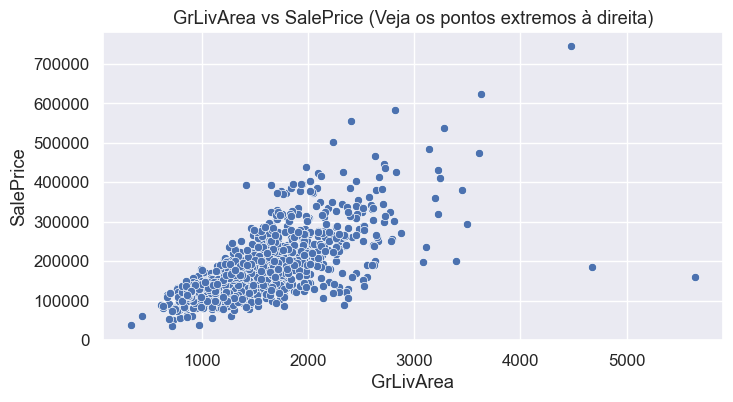

In [68]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df_limpo['GrLivArea'], y=df_limpo['SalePrice'])
plt.title("GrLivArea vs SalePrice (Veja os pontos extremos à direita)")
plt.show()

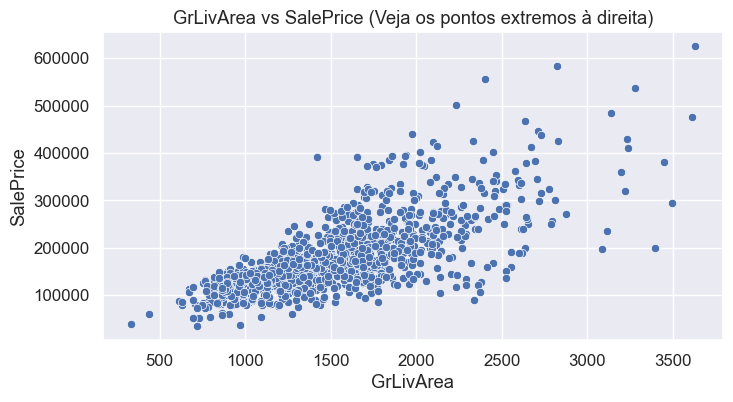

In [69]:
condicao_outlier_area = df_limpo['GrLivArea'] > 4000
df_limpo = df_limpo.drop(df_limpo[condicao_outlier_area].index)
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df_limpo['GrLivArea'], y=df_limpo['SalePrice'])
plt.title("GrLivArea vs SalePrice (Veja os pontos extremos à direita)")
plt.show()

In [70]:
COLUNAS_PARA_APLICAR_IQR = ['LotArea', 'TotalBsmtSF']

for col in COLUNAS_PARA_APLICAR_IQR:
    Q1 = df_limpo[col].quantile(0.25)
    Q3 = df_limpo[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    df_limpo = df_limpo[
        (df_limpo[col] >= limite_inferior) & (df_limpo[col] <= limite_superior) | 
        df_limpo[col].isnull()
    ]

print(f"Tamanho do dataset DEPOIS de remover outliers: {df_limpo.shape}")

Tamanho do dataset DEPOIS de remover outliers: (1067, 81)


In [71]:

# Separar numéricas e categóricas
colunas_numericas = df_limpo.select_dtypes(include=[np.number]).columns
colunas_categoricas = df_limpo.select_dtypes(exclude=[np.number]).columns

# Aplicar nas colunas NUMÉRICAS
for col in colunas_numericas:
    if df_limpo[col].isnull().sum() > 0:
        # Busca a estratégia no dicionário, se não achar usa a ESTRATEGIA_NUMERICA_PADRAO
        estr = ESTRATEGIAS_NUMERICAS_POR_COLUNA.get(col, ESTRATEGIA_NUMERICA_PADRAO)
        
        if estr == 'zero':
            df_limpo[col] = df_limpo[col].fillna(0)
        elif estr == 'media':
            df_limpo[col] = df_limpo[col].fillna(df_limpo[col].mean())
        elif estr == 'mediana':
            df_limpo[col] = df_limpo[col].fillna(df_limpo[col].median())

# Aplicar nas colunas CATEGÓRICAS restantes
for col in colunas_categoricas:
    if df_limpo[col].isnull().sum() > 0:
        if ESTRATEGIA_CATEGORICA_PADRAO == 'moda':
            # Pega o valor mais frequente (moda) e preenche
            df_limpo[col] = df_limpo[col].fillna(df_limpo[col].mode()[0])
        elif ESTRATEGIA_CATEGORICA_PADRAO == 'ausente':
            df_limpo[col] = df_limpo[col].fillna('Ausente')

nulos_finais = df_limpo.isnull().sum().sum()

print(f"Total de nulos agora: {nulos_finais}")

if nulos_finais != 0:
    print("Atenção: Ainda restaram alguns valores nulos. Verifique:")
    print(df_limpo.isnull().sum()[df_limpo.isnull().sum() > 0])

Total de nulos agora: 0


In [72]:

print("⏳ A gerar os dois datasets para o teste...\n")

# --- VERSÃO 1: Com One-Hot Encoding (Variáveis Dummy) ---
df_ohe = pd.get_dummies(df_limpo, drop_first=True)
print(f"✅ Versão 1 (One-Hot Encoding) criada! Formato: {df_ohe.shape}")

# --- VERSÃO 2: Sem OHE (Usando Ordinal Encoding) ---
df_ordinal = df_limpo.copy()
colunas_categoricas = df_ordinal.select_dtypes(exclude=[np.number]).columns

# O OrdinalEncoder transforma textos em números inteiros (0, 1, 2...) na mesma coluna
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_ordinal[colunas_categoricas] = encoder.fit_transform(df_ordinal[colunas_categoricas])

print(f"✅ Versão 2 (Ordinal Encoding) criada! Formato: {df_ordinal.shape}")

⏳ A gerar os dois datasets para o teste...

✅ Versão 1 (One-Hot Encoding) criada! Formato: (1067, 241)
✅ Versão 2 (Ordinal Encoding) criada! Formato: (1067, 81)


In [73]:
df_teste_stats = df_ordinal.copy()
X_stats = df_teste_stats.drop(columns=['SalePrice'])
y_stats = df_teste_stats['SalePrice']

print("="*60)
print("🔍 1. MATRIZ DE PEARSON (Pares com Colinearidade > 0.75)")
print("="*60)
corr_matrix = X_stats.corr(method='pearson').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
alta_colinearidade = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i+1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > 0.75
]

if alta_colinearidade:
    for var1, var2, corr in sorted(alta_colinearidade, key=lambda x: x[2], reverse=True):
        print(f"⚠️ {var1:<15} e {var2:<15} | Correlação: {corr:.3f}")
else:
    print("✅ Nenhuma alta correlação direta encontrada!")


print("\n" + "="*60)
print("📊 2. TESTE VIF - MULTICOLINEARIDADE (Top 15)")
print("   (Regra geral: VIF > 10 indica problema grave)")
print("="*60)
# Adiciona constante para o modelo matemático do VIF funcionar corretamente
X_vif = add_constant(X_stats) 
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
# Ignoramos avisos de divisão por zero caso existam colunas constantes
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Removemos a constante do print e ordenamos
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_data.head(15).to_string(index=False))


print("\n" + "="*60)
print("🎯 3. TESTE F - IMPORTÂNCIA LINEAR (Top 10)")
print("   (Mede impacto direto da coluna no SalePrice)")
print("="*60)
f_values, p_values_f = f_regression(X_stats, y_stats)
df_f_test = pd.DataFrame({'Feature': X_stats.columns, 'F_Score': f_values, 'P_Value': p_values_f})
df_f_test = df_f_test.sort_values(by='F_Score', ascending=False)
print(df_f_test.head(10).to_string(index=False))


print("\n" + "="*60)
print("🏷️ 4. TESTE H (Kruskal-Wallis) - CATEGÓRICAS (Top 10)")
print("   (Impacto estatístico das categorias no SalePrice)")
print("="*60)
# Para o teste H, usamos os textos originais do df_limpo para agrupar
colunas_categoricas_originais = df_limpo.select_dtypes(exclude=[np.number]).columns
h_results = []

for col in colunas_categoricas_originais:
    # Agrupa os preços reais pelas categorias (ex: Vizinhanças)
    grupos = [grupo['SalePrice'].values for nome, grupo in df_limpo.groupby(col)]
    # O teste exige pelo menos 2 categorias para comparar
    if len(grupos) > 1:
        stat, p_value_h = kruskal(*grupos)
        h_results.append({'Feature': col, 'H_Statistic': stat, 'P_Value': p_value_h})

df_h_test = pd.DataFrame(h_results).sort_values(by='H_Statistic', ascending=False)
print(df_h_test.head(10).to_string(index=False))

🔍 1. MATRIZ DE PEARSON (Pares com Colinearidade > 0.75)
⚠️ PoolArea        e PoolQC          | Correlação: 0.994
⚠️ GarageCars      e GarageArea      | Correlação: 0.887
⚠️ TotalBsmtSF     e 1stFlrSF        | Correlação: 0.872
⚠️ Exterior1st     e Exterior2nd     | Correlação: 0.857
⚠️ GrLivArea       e TotRmsAbvGrd    | Correlação: 0.833
⚠️ BsmtFinType2    e BsmtFinSF2      | Correlação: 0.752

📊 2. TESTE VIF - MULTICOLINEARIDADE (Top 15)
   (Regra geral: VIF > 10 indica problema grave)
     Feature       VIF
  BsmtFinSF1       inf
 TotalBsmtSF       inf
   BsmtUnfSF       inf
  BsmtFinSF2       inf
    2ndFlrSF       inf
LowQualFinSF       inf
   GrLivArea       inf
    1stFlrSF       inf
      PoolQC 95.906262
    PoolArea 94.484887
   YearBuilt  8.081245
  GarageCars  6.647736
  MSSubClass  6.174923
  GarageArea  5.798062
TotRmsAbvGrd  5.573549

🎯 3. TESTE F - IMPORTÂNCIA LINEAR (Top 10)
   (Mede impacto direto da coluna no SalePrice)
    Feature     F_Score       P_Value
OverallQu

⏳ A gerar os gráficos de correlação...


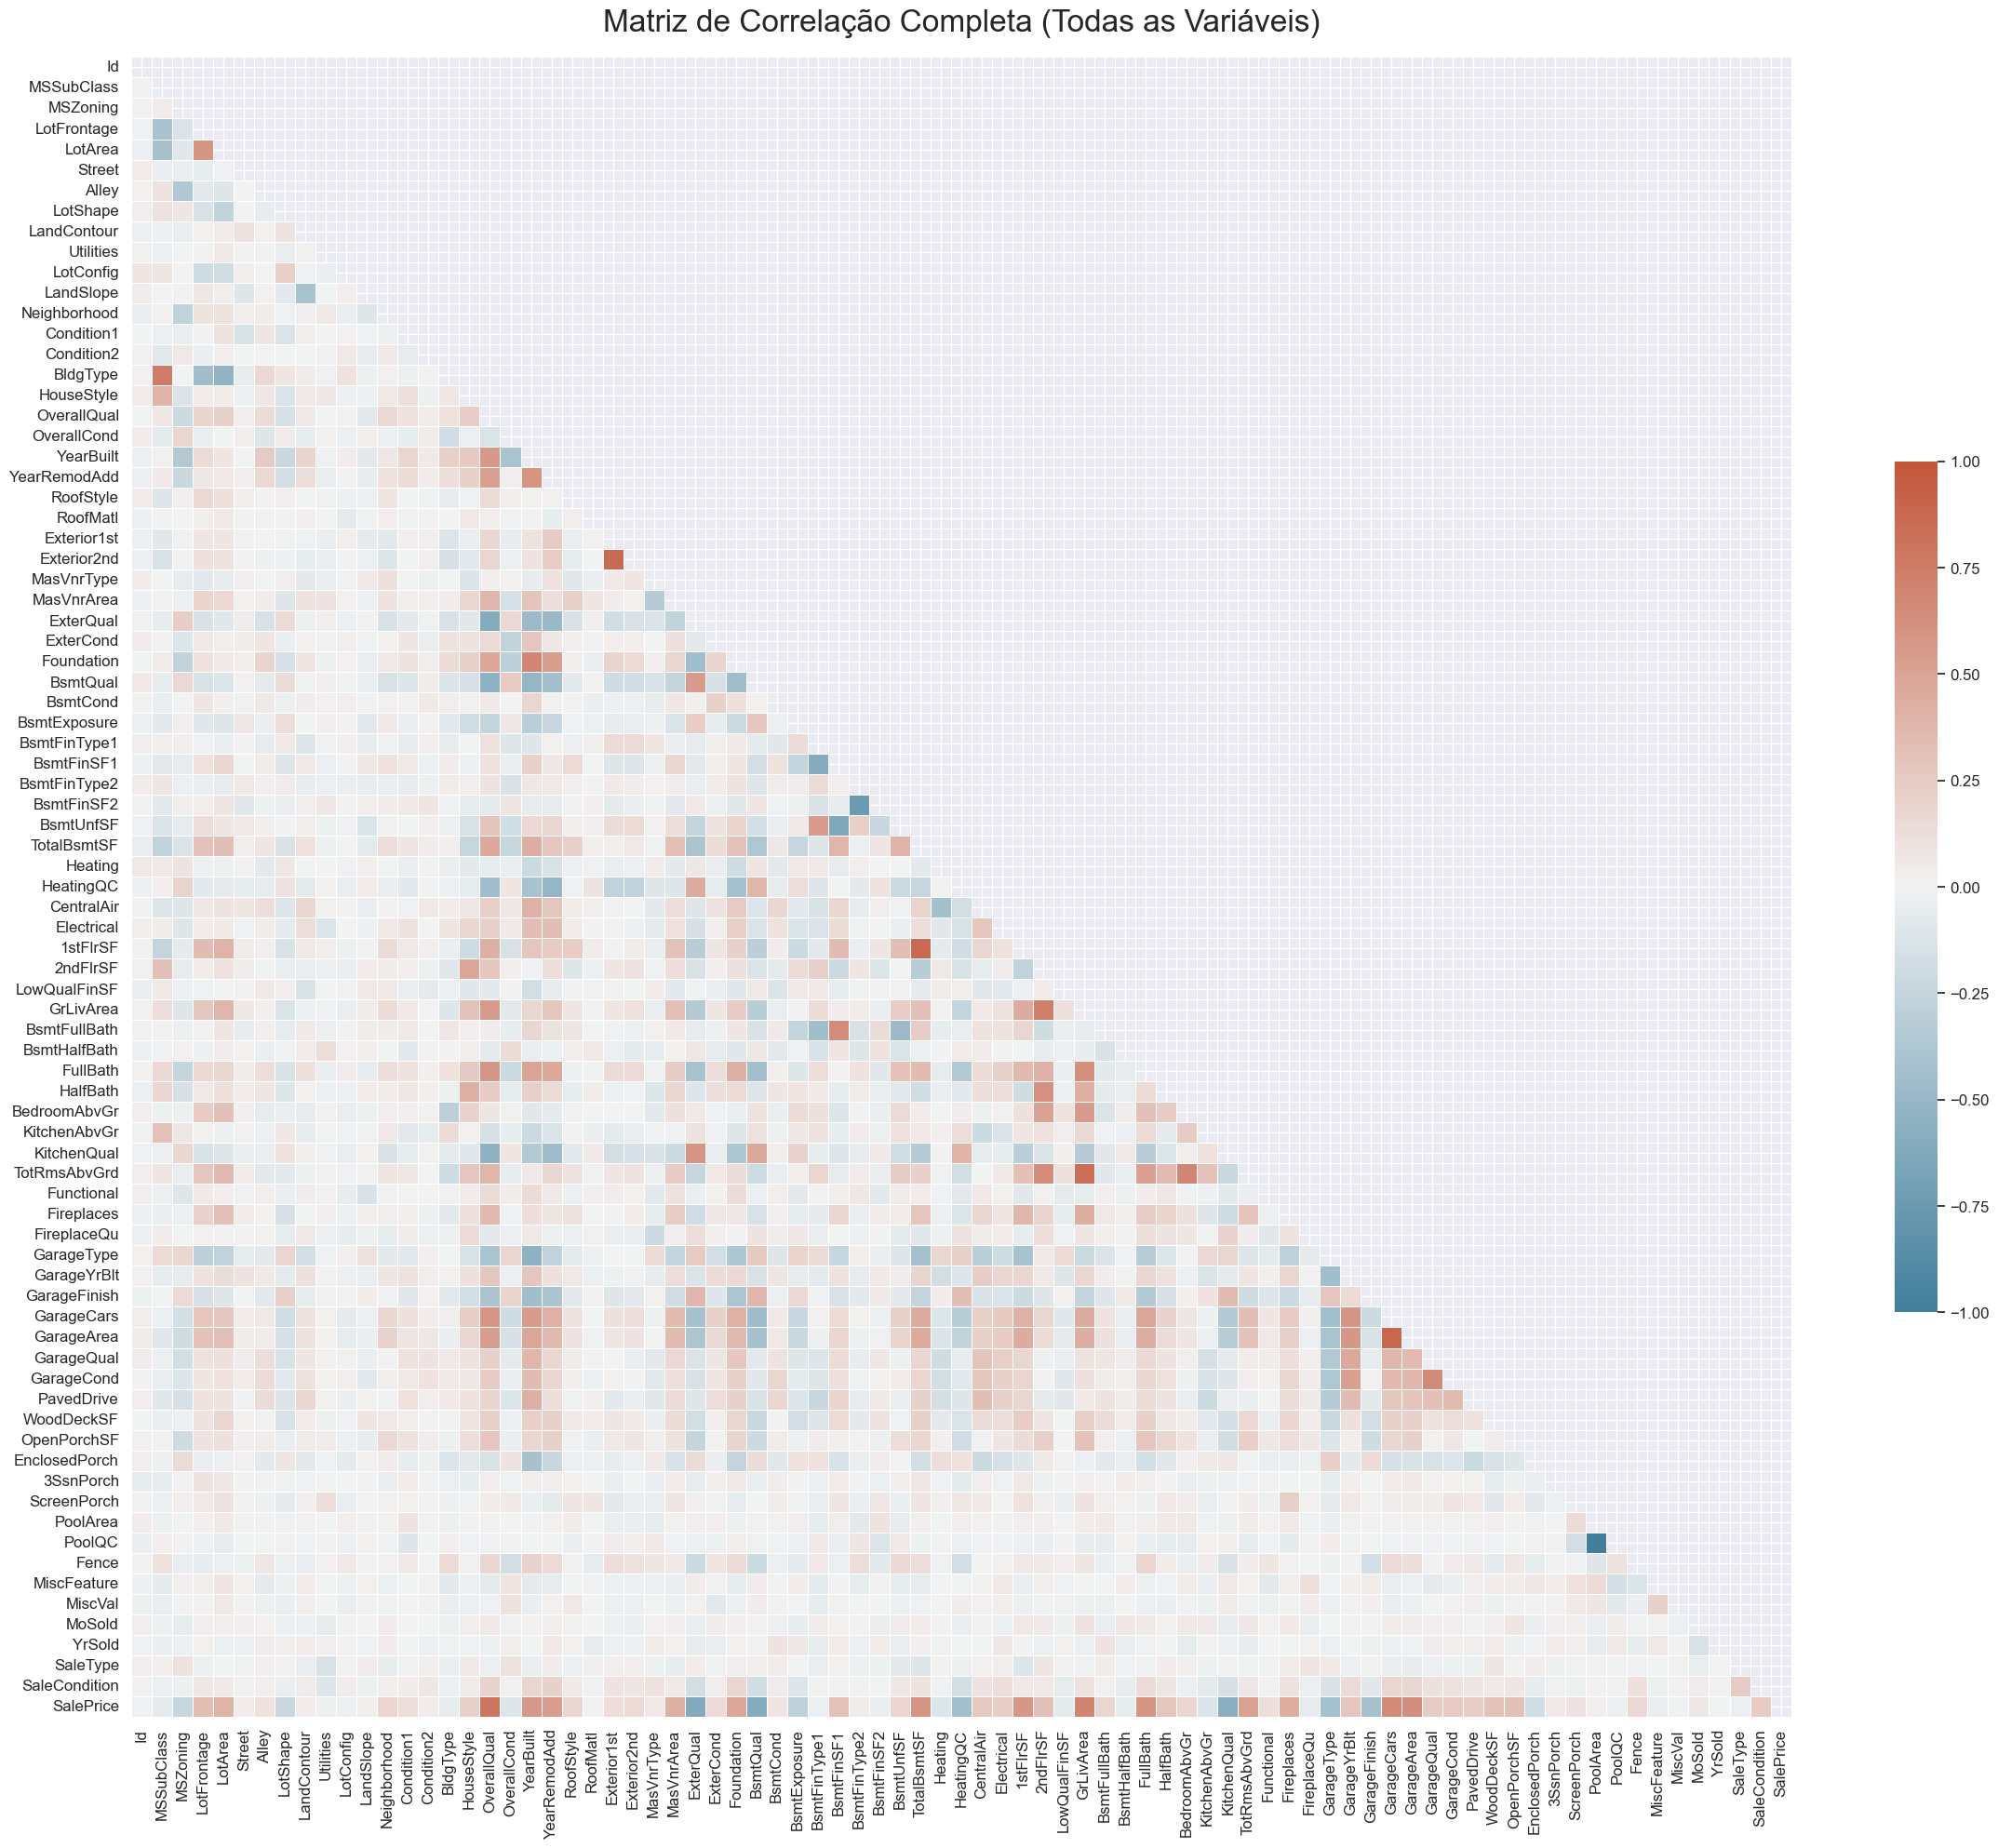

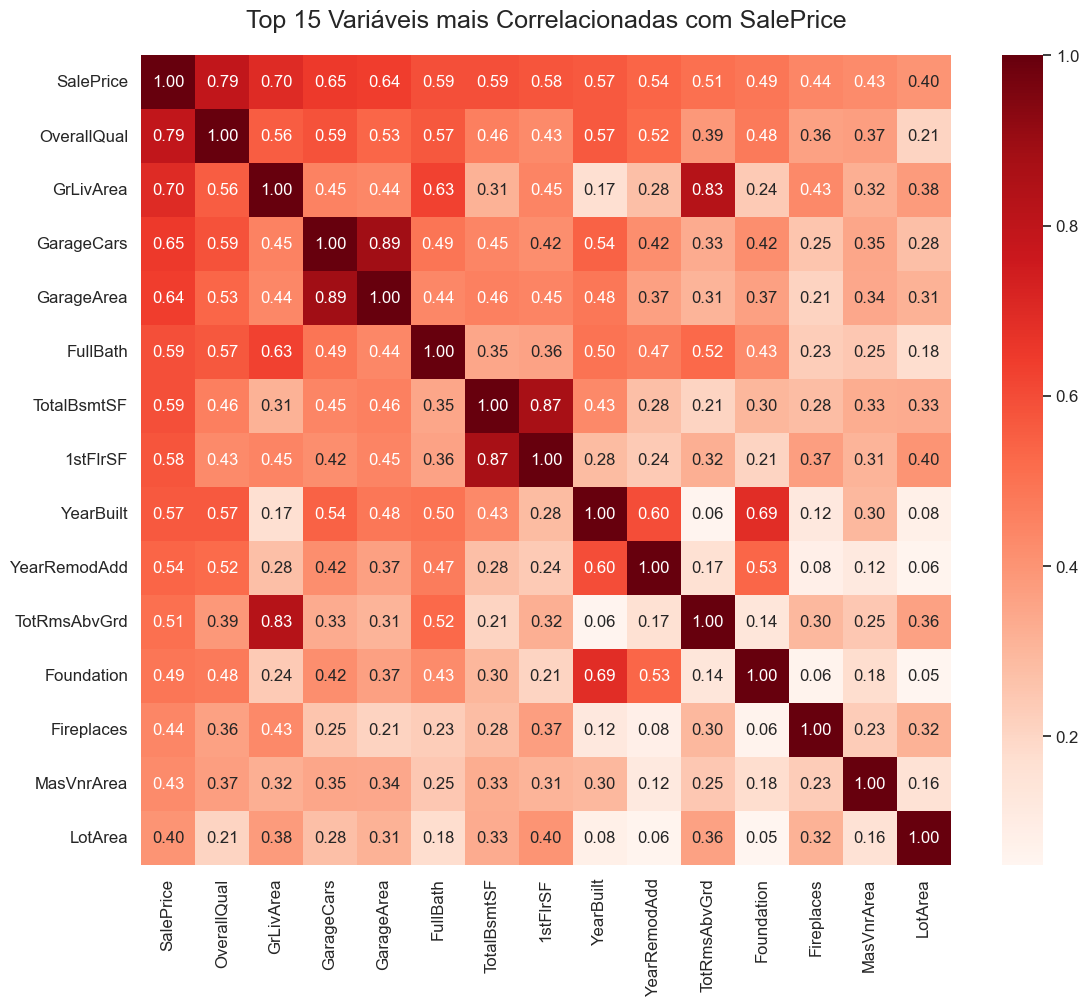

In [74]:
# ==========================================
# 📊 VISUALIZAÇÃO: MATRIZ DE CORRELAÇÃO DE PEARSON
# ==========================================


# Calcula a matriz de correlação completa (usando o df_teste_stats que tem o alvo)
corr_matrix = df_teste_stats.corr(method='pearson')

print("⏳ A gerar os gráficos de correlação...")

# ---------------------------------------------------------
# GRÁFICO 1: Matriz de Correlação Completa
# ---------------------------------------------------------
plt.figure(figsize=(24, 20))

# Criar uma máscara para esconder o triângulo superior (evita informação duplicada)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Escolher a paleta de cores (Azul = correlação negativa, Vermelho = correlação positiva)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Plotar o heatmap completo (sem números dentro, pois são muitas colunas)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Matriz de Correlação Completa (Todas as Variáveis)', fontsize=24, pad=20)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRÁFICO 2: Zoom nas Variáveis mais correlacionadas com 'SalePrice'
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))

# Selecionar as 15 variáveis com maior correlação absoluta com o preço
k = 15 
cols_top = corr_matrix.nlargest(k, 'SalePrice')['SalePrice'].index
cm_top = np.corrcoef(df_teste_stats[cols_top].values.T)

# Plotar o heatmap focado (agora com os números dentro)
sns.set(font_scale=1.1)
hm = sns.heatmap(cm_top, cbar=True, annot=True, square=True, fmt='.2f', 
                 annot_kws={'size': 12}, yticklabels=cols_top.values, 
                 xticklabels=cols_top.values, cmap='Reds')

plt.title(f'Top {k} Variáveis mais Correlacionadas com SalePrice', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

In [75]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Floresta Aleatória": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(),
    "Ensemble (GBM)": GradientBoostingRegressor(random_state=42)
}

In [76]:
def avaliar_dataset(nome_versao, df_dados):
    print(f"\n{'='*50}")
    print(f"🏆 AVALIAÇÃO: {nome_versao}")
    print(f"{'='*50}")
    
    # Separação
    X = df_dados.drop(columns=['SalePrice'])
    y = df_dados['SalePrice']
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Escalonamento
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Log no Preço
    y_train_log = np.log1p(y_train)
    
    resultados_locais = {}
    
    # Treinamento e Avaliação
    for nome, modelo in modelos.items():
        try:
            modelo.fit(X_train_scaled, y_train_log)
            preds_log = modelo.predict(X_val_scaled)
            preds = np.expm1(preds_log)
            preds = np.clip(preds, a_min=0, a_max=None)
            
            erro_rmsle = np.sqrt(mean_squared_log_error(y_val, preds))
            resultados_locais[nome] = erro_rmsle
            
            print(f"✅ {nome:<20} | RMSLE: {erro_rmsle:.5f}")
        except Exception as e:
            print(f"❌ {nome:<20} | Erro: {e}")
            
    vencedor = min(resultados_locais, key=resultados_locais.get)
    print(f"\n🥇 Vencedor ({nome_versao}): {vencedor} (RMSLE: {resultados_locais[vencedor]:.5f})")
    
    return resultados_locais

# 3. Rodamos o pipeline para as duas versões do dataset!
resultados_ohe = avaliar_dataset("VERSÃO 1: COM One-Hot Encoding", df_ohe)
resultados_ordinal = avaliar_dataset("VERSÃO 2: SEM One-Hot (Ordinal Encoding)", df_ordinal)

# ==========================================
# 📊 CONCLUSÃO DO TESTE
# ==========================================
print("\n" + "*"*60)
print("🎯 RESUMO DA BATALHA DE ENCODING:")
print("*"*60)

for nome in modelos.keys():
    if nome in resultados_ohe and nome in resultados_ordinal:
        melhor = "OHE" if resultados_ohe[nome] < resultados_ordinal[nome] else "Ordinal"
        print(f"{nome:<20}: OHE ({resultados_ohe[nome]:.5f}) vs Ordinal ({resultados_ordinal[nome]:.5f}) --> Vencedor: {melhor}")


🏆 AVALIAÇÃO: VERSÃO 1: COM One-Hot Encoding
✅ Regressão Linear     | RMSLE: 0.11040
✅ Árvore de Decisão    | RMSLE: 0.18736
✅ Floresta Aleatória   | RMSLE: 0.12010
✅ KNN                  | RMSLE: 0.16753
✅ SVM                  | RMSLE: 0.16459
✅ Ensemble (GBM)       | RMSLE: 0.11058

🥇 Vencedor (VERSÃO 1: COM One-Hot Encoding): Regressão Linear (RMSLE: 0.11040)

🏆 AVALIAÇÃO: VERSÃO 2: SEM One-Hot (Ordinal Encoding)
✅ Regressão Linear     | RMSLE: 0.10016
✅ Árvore de Decisão    | RMSLE: 0.21196
✅ Floresta Aleatória   | RMSLE: 0.12260
✅ KNN                  | RMSLE: 0.15616
✅ SVM                  | RMSLE: 0.13655
✅ Ensemble (GBM)       | RMSLE: 0.10987

🥇 Vencedor (VERSÃO 2: SEM One-Hot (Ordinal Encoding)): Regressão Linear (RMSLE: 0.10016)

************************************************************
🎯 RESUMO DA BATALHA DE ENCODING:
************************************************************
Regressão Linear    : OHE (0.11040) vs Ordinal (0.10016) --> Vencedor: Ordinal
Árvore de Decis